##### Objectif : Experimnet before finalizing pipeline
##### Steps :
Load sample images.

Test skull stripping.

Compare before/after.

Apply Z-score normalization.

Visualize intensity histograms.

Test augmentation strategies:

rotation

zoom

flip

Compare weak vs strong augmentation.

Decide final augmentation policy.

Document decisions clearly.

In [1]:
#import necessary libraries :
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
from skimage import exposure, filters, morphology
import nibabel as nib  # For neuroimaging formats if needed
import warnings
warnings.filterwarnings('ignore')

C:\Users\kheza\AppData\Roaming\Python\Python313\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


In [2]:
os.makedirs('reports/figures/preprocessing', exist_ok=True)

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
#2- load the dataset
data_dir = Path('../data/raw/train').resolve()
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
print(f"Classes found: {class_names}")
if not os.path.exists(data_dir):
    print(f"Directory {data_dir} does not exist. Please check the path.")
else:
    print(f"Directory {data_dir} exists. Proceeding with data loading.")

Classes found: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Directory C:\Users\kheza\Desktop\NeuroSight_AI\notebooks\data\raw\train exists. Proceeding with data loading.


loaded sample images for classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


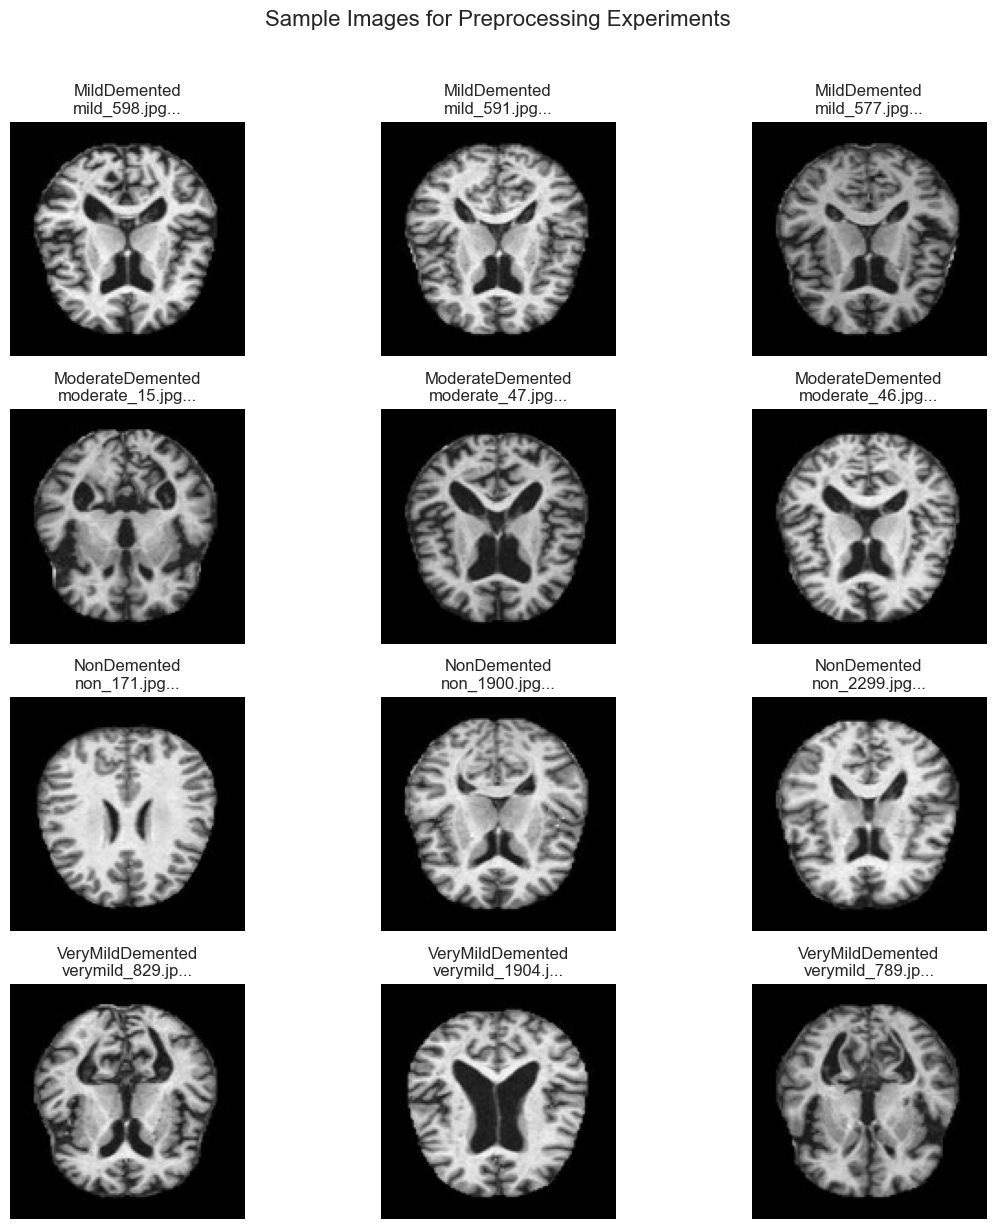

In [4]:
def load_sample_images(dataset_path, class_names, samples_per_class=3):
    """Load sample images from each class"""
    samples = {}
    
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_path):
            print(f"⚠️ Warning: {class_name} folder not found")
            continue
            
        images = [f for f in os.listdir(class_path) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(images) == 0:
            continue
            
        # Select random samples
        selected = np.random.choice(images, min(samples_per_class, len(images)), replace=False)
        
        class_samples = []
        for img_file in selected:
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                # Convert to RGB for display, keep original for processing
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                class_samples.append({
                    'file': img_file,
                    'original': img,
                    'rgb': img_rgb,
                    'path': img_path
                })
        
        samples[class_name] = class_samples
    
    return samples

sample_images = load_sample_images(data_dir, class_names)
print(f"loaded sample images for classes: {list(sample_images.keys())}")
fig, axes = plt.subplots(len(sample_images), 3, figsize=(12, len(sample_images)*3))

if len(sample_images) == 1:
    axes = axes.reshape(1, -1)

for row, (class_name, samples) in enumerate(sample_images.items()):
    for col in range(3):
        if col < len(samples):
            axes[row, col].imshow(samples[col]['rgb'])
            axes[row, col].set_title(f"{class_name}\n{samples[col]['file'][:15]}...")
        axes[row, col].axis('off')

plt.suptitle('Sample Images for Preprocessing Experiments', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

#### Skull stripping : a specific function for mri 


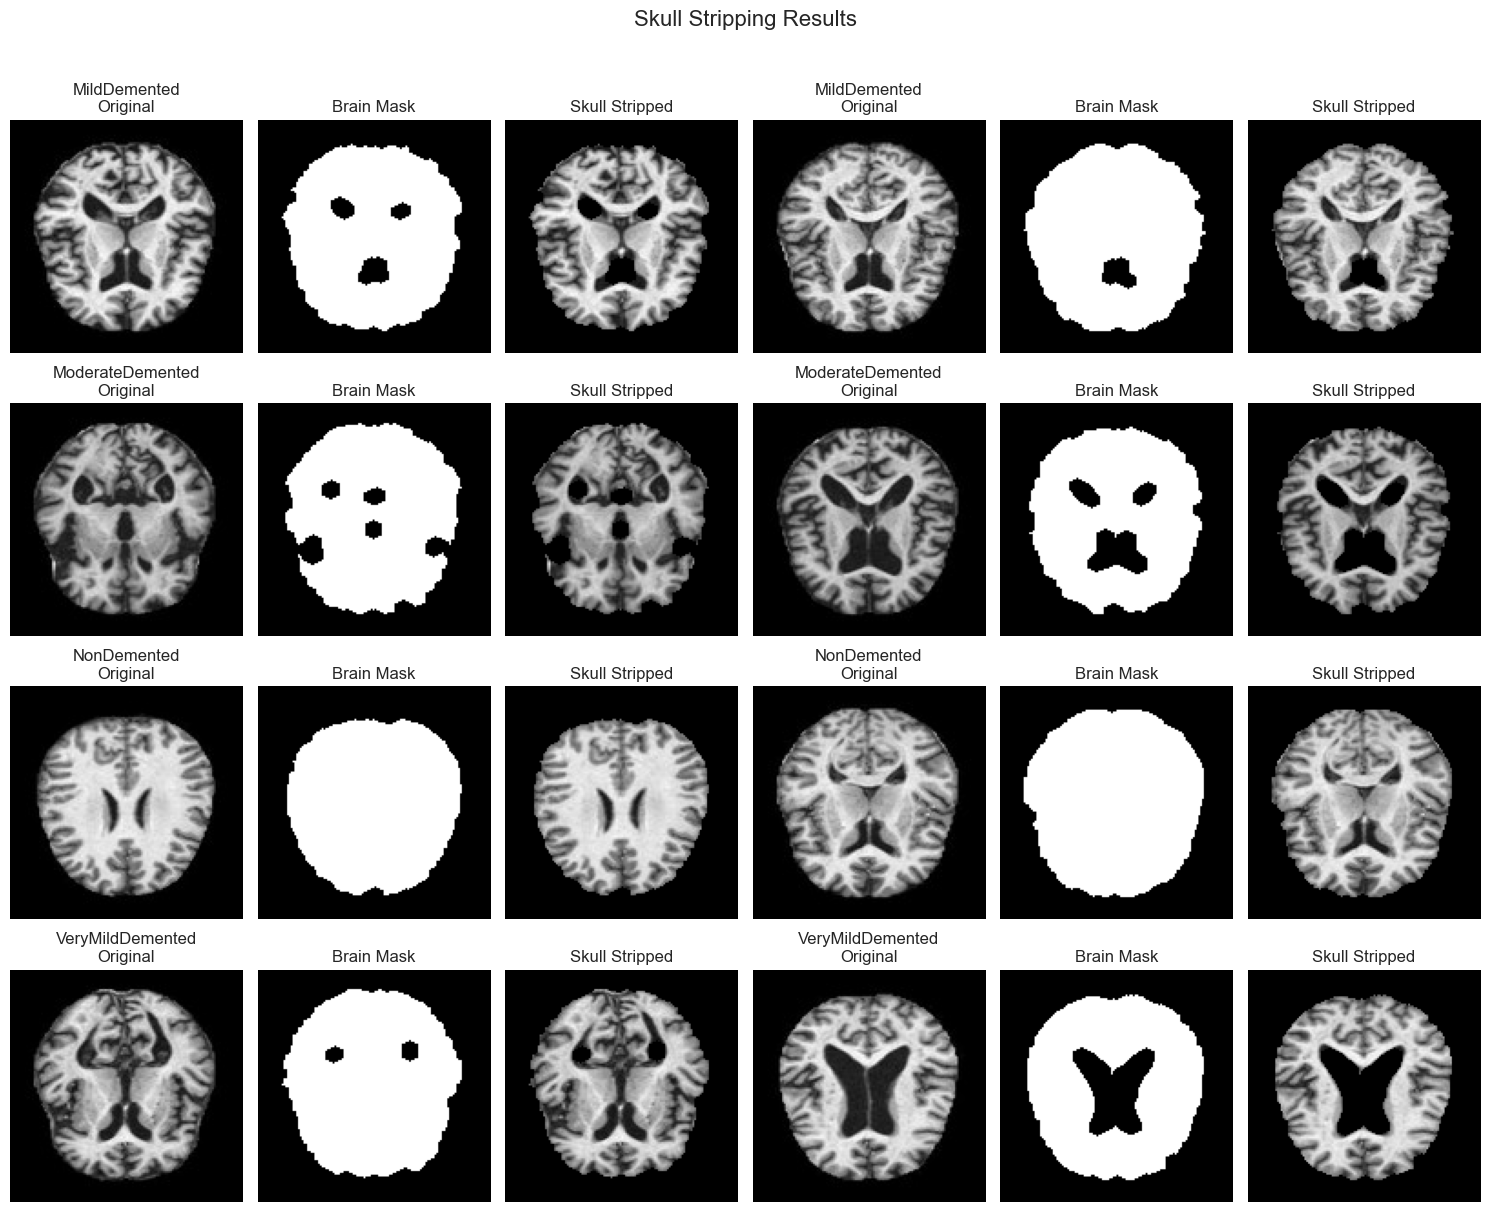

In [5]:
def skull_stripping(image):
    """Simple skull stripping using thresholding and morphological operations"""
    # Convert to grayscale if needed
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Apply threshold to separate brain from skull
    _, thresh = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Morphological operations to clean up
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find largest connected component (assumed to be brain)
    num_labels, labels = cv2.connectedComponents(closed)
    if num_labels > 1:
        # Get the largest component (excluding background)
        largest_label = 1 + np.argmax([np.sum(labels == i) for i in range(1, num_labels)])
        brain_mask = (labels == largest_label).astype(np.uint8) * 255
    else:
        brain_mask = closed
    
    # Apply mask to original image
    if len(image.shape) == 3:
        brain_masked = cv2.bitwise_and(image, image, mask=brain_mask)
    else:
        brain_masked = cv2.bitwise_and(image, image, mask=brain_mask)
    
    return brain_masked, brain_mask

#test the fct on samples :
fig, axes = plt.subplots(len(sample_images), 6, figsize=(15, len(sample_images)*3))

for row, (class_name, samples) in enumerate(sample_images.items()):
    for col, sample in enumerate(samples[:2]):  # Test on first 2 samples per class
        # Apply skull stripping
        brain_stripped, mask = skull_stripping(sample['original'])
        
        # Convert to RGB for display if needed
        if len(brain_stripped.shape) == 3:
            brain_stripped_rgb = cv2.cvtColor(brain_stripped, cv2.COLOR_BGR2RGB)
        else:
            brain_stripped_rgb = cv2.cvtColor(brain_stripped, cv2.COLOR_GRAY2RGB)
        
        # Display original
        axes[row, col*3].imshow(sample['rgb'])
        axes[row, col*3].set_title(f'{class_name}\nOriginal')
        axes[row, col*3].axis('off')
        
        # Display mask
        axes[row, col*3 + 1].imshow(mask, cmap='gray')
        axes[row, col*3 + 1].set_title('Brain Mask')
        axes[row, col*3 + 1].axis('off')
        
        # Display stripped
        axes[row, col*3 + 2].imshow(brain_stripped_rgb)
        axes[row, col*3 + 2].set_title('Skull Stripped')
        axes[row, col*3 + 2].axis('off')

plt.suptitle('Skull Stripping Results', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/skull_stripping.png', dpi=300, bbox_inches='tight')
plt.show()

#### we dont need skull stripping on this dataset 

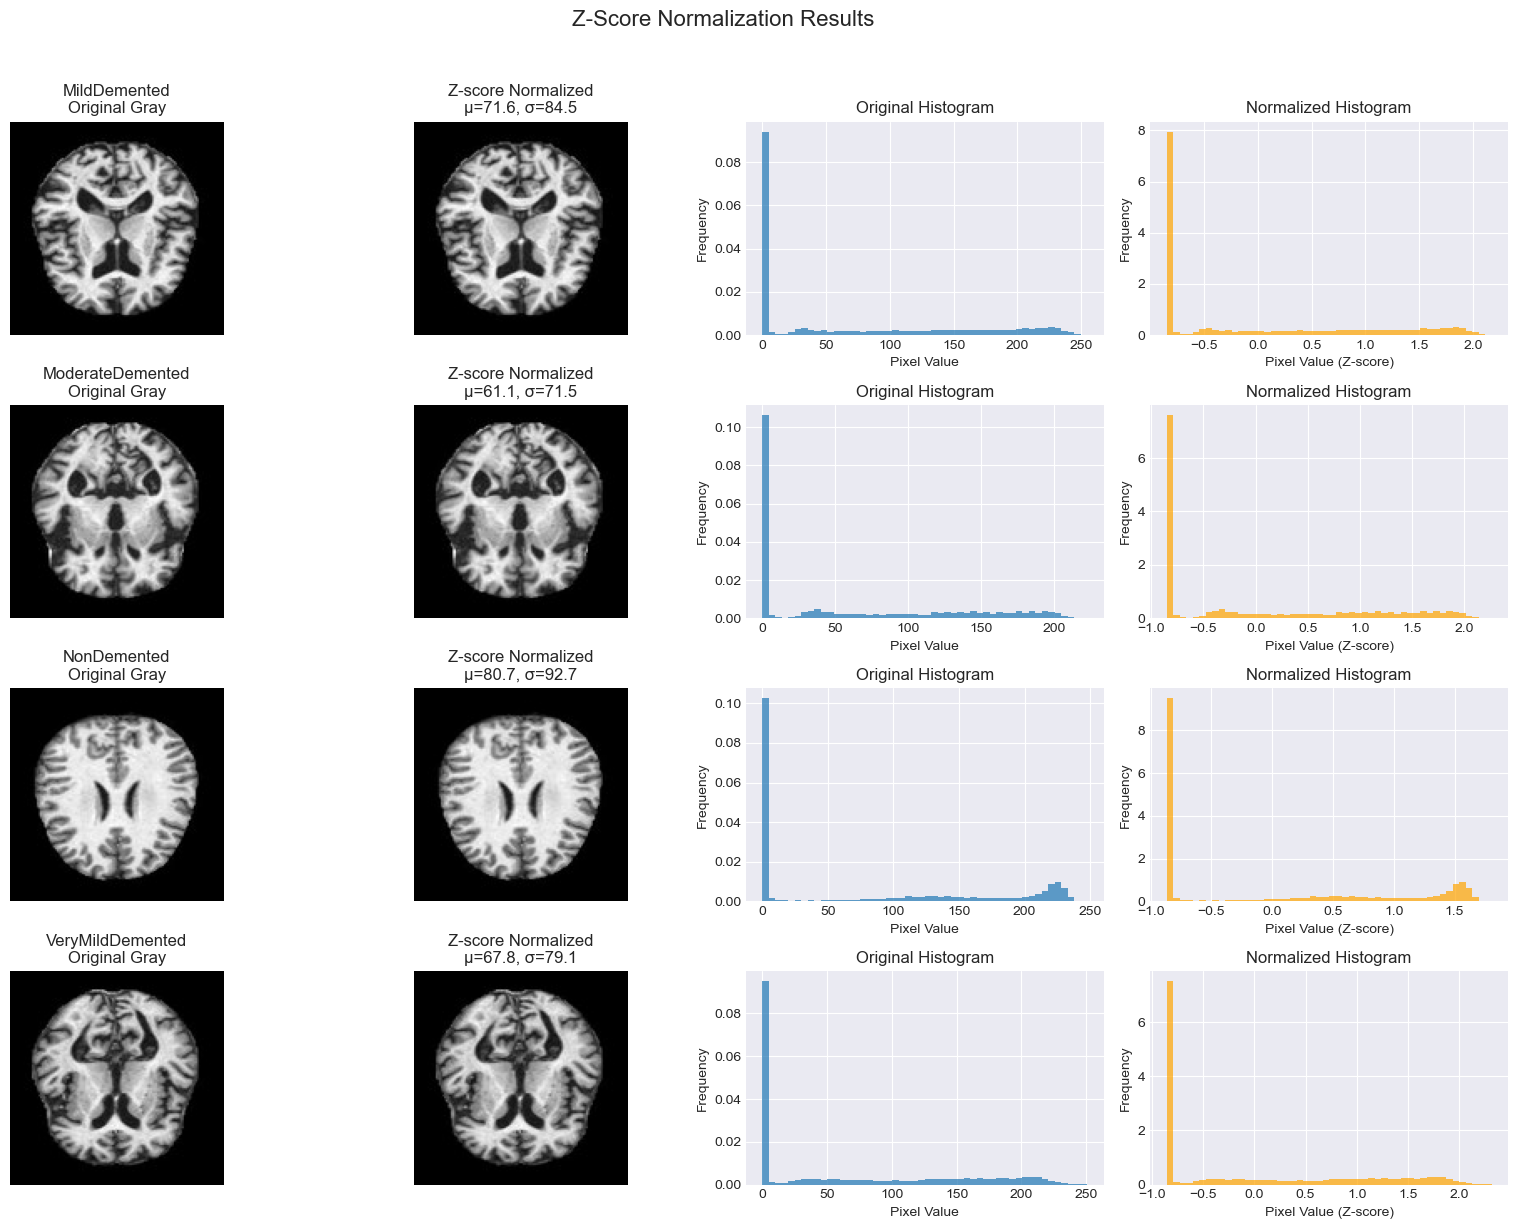

In [6]:
# 4- Z-score normalization
def z_score_normalization(image):
    """Apply Z-score normalization to the image"""
    if len(image.shape) == 3:
        # Convert to grayscale for normalization
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    
    # Convert to float
    gray_float = gray.astype(np.float32)
    
    # Calculate mean and std
    mean = np.mean(gray_float)
    std = np.std(gray_float)
    
    # Apply Z-score normalization
    if std > 0:
        normalized = (gray_float - mean) / std
    else:
        normalized = gray_float - mean
    
    return normalized, mean, std

# Test Z-score normalization 
fig, axes = plt.subplots(len(sample_images), 4, figsize=(16, len(sample_images)*3))

for row, (class_name, samples) in enumerate(sample_images.items()):
    for col, sample in enumerate(samples[:1]):  # Test on first sample per class
        # Convert to grayscale if needed
        if len(sample['original'].shape) == 3:
            gray = cv2.cvtColor(sample['original'], cv2.COLOR_BGR2GRAY)
        else:
            gray = sample['original'].copy()
        
        # Apply Z-score normalization
        normalized, mean, std = z_score_normalization(sample['original'])
        
        # Display original grayscale
        axes[row, 0].imshow(gray, cmap='gray')
        axes[row, 0].set_title(f'{class_name}\nOriginal Gray')
        axes[row, 0].axis('off')
        
        # Display normalized
        axes[row, 1].imshow(normalized, cmap='gray')
        axes[row, 1].set_title(f'Z-score Normalized\nμ={mean:.1f}, σ={std:.1f}')
        axes[row, 1].axis('off')
        
        # Plot histograms
        axes[row, 2].hist(gray.flatten(), bins=50, alpha=0.7, label='Original', density=True)
        axes[row, 2].set_title('Original Histogram')
        axes[row, 2].set_xlabel('Pixel Value')
        axes[row, 2].set_ylabel('Frequency')
        
        axes[row, 3].hist(normalized.flatten(), bins=50, alpha=0.7, label='Normalized', density=True, color='orange')
        axes[row, 3].set_title('Normalized Histogram')
        axes[row, 3].set_xlabel('Pixel Value (Z-score)')
        axes[row, 3].set_ylabel('Frequency')

plt.suptitle('Z-Score Normalization Results', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/zscore_normalization.png', dpi=300, bbox_inches='tight')
plt.show()


##### Z-score normalization helps centers the data which helps networks converge faster

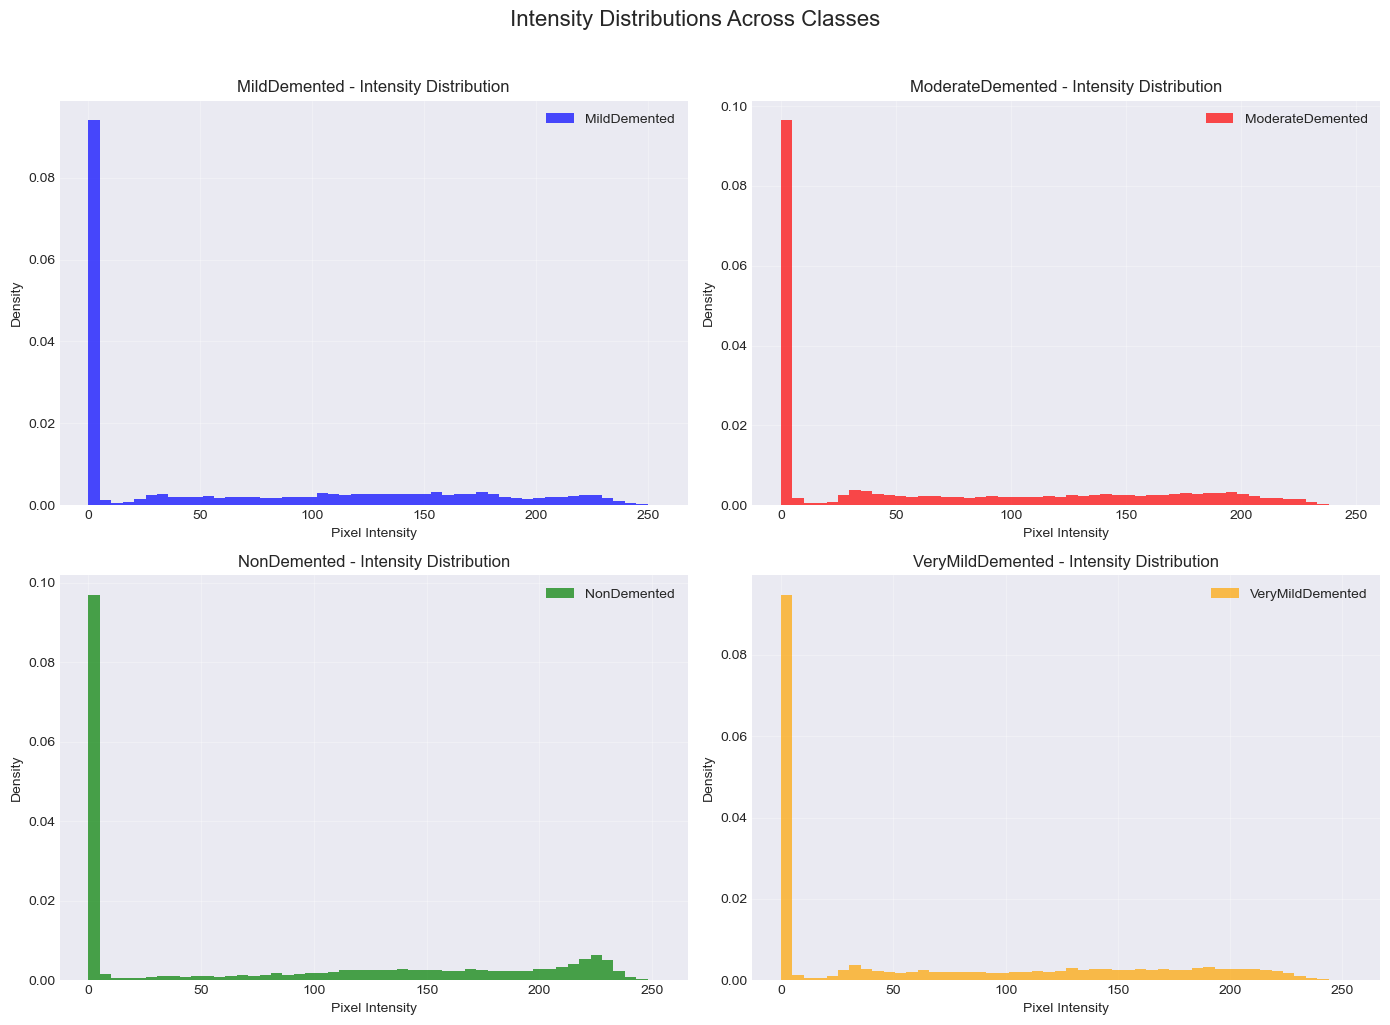

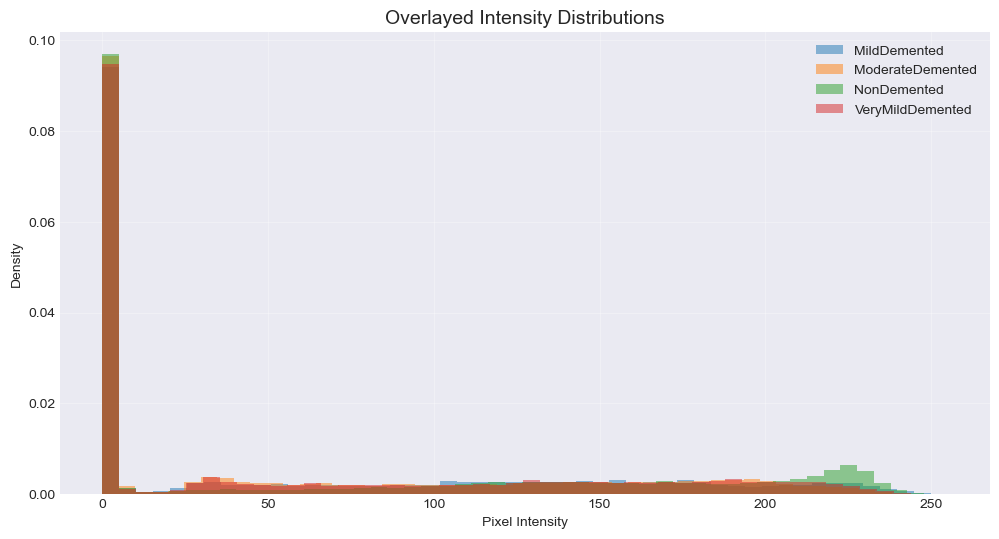

In [7]:
# 5- intensity normalization using histogram equalization
def analyze_intensity_distribution(images_dict):
    """Analyze and plot intensity distributions across classes"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    colors = ['blue', 'red', 'green', 'orange']
    
    for idx, (class_name, samples) in enumerate(images_dict.items()):
        if idx >= 4:
            break
            
        ax = axes[idx]
        
        # Collect all pixel intensities for this class
        all_pixels = []
        for sample in samples:
            if len(sample['original'].shape) == 3:
                gray = cv2.cvtColor(sample['original'], cv2.COLOR_BGR2GRAY)
            else:
                gray = sample['original'].copy()
            all_pixels.extend(gray.flatten())
        
        # Plot histogram
        ax.hist(all_pixels, bins=50, alpha=0.7, color=colors[idx % len(colors)], 
                density=True, label=f'{class_name}')
        ax.set_title(f'{class_name} - Intensity Distribution')
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Intensity Distributions Across Classes', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig('reports/figures/preprocessing/intensity_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Overlay all distributions
    plt.figure(figsize=(12, 6))
    for idx, (class_name, samples) in enumerate(images_dict.items()):
        all_pixels = []
        for sample in samples:
            if len(sample['original'].shape) == 3:
                gray = cv2.cvtColor(sample['original'], cv2.COLOR_BGR2GRAY)
            else:
                gray = sample['original'].copy()
            all_pixels.extend(gray.flatten())
        
        plt.hist(all_pixels, bins=50, alpha=0.5, label=class_name, density=True)
    
    plt.title('Overlayed Intensity Distributions', fontsize=14)
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('reports/figures/preprocessing/intensity_overlay.png', dpi=300, bbox_inches='tight')
    plt.show()

analyze_intensity_distribution(sample_images)

1️⃣ Strong peak at intensity ≈ 0 (all classes)

Large amount of black background.

Dominates pixel distribution.

2️⃣ High overlap between class distributions

Mild, Moderate, NonDemented, VeryMild have very similar intensity ranges.

No clear global intensity separation between classes.

3️⃣ Slight brightness variations across classes

Minor shifts exist but are subtle.

Not strong enough for intensity-based classification.

In [8]:
#test Augmentation strategies

# Define augmentation pipelines
def get_augmentation_pipelines():
    """Define weak and strong augmentation pipelines"""
    
    # Weak augmentation - minimal changes
    weak_aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=10, p=0.5),
    ])
    
    # Strong augmentation - aggressive changes
    strong_aug = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.Rotate(limit=30, p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.2),
        A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2)
    ])
    
    # Individual augmentations for testing
    individual_augs = {
        'rotation_10': A.Rotate(limit=10, p=1.0),
        'rotation_30': A.Rotate(limit=30, p=1.0),
        'zoom_1.1': A.RandomScale(scale_limit=0.1, p=1.0),
        'zoom_1.3': A.RandomScale(scale_limit=0.3, p=1.0),
        'flip_h': A.HorizontalFlip(p=1.0),
        'flip_v': A.VerticalFlip(p=1.0),
        'brightness': A.RandomBrightnessContrast(brightness_limit=0.2, p=1.0),
        'noise': A.GaussNoise(var_limit=30.0, p=1.0)
    }
    
    return weak_aug, strong_aug, individual_augs

weak_aug, strong_aug, individual_augs = get_augmentation_pipelines()

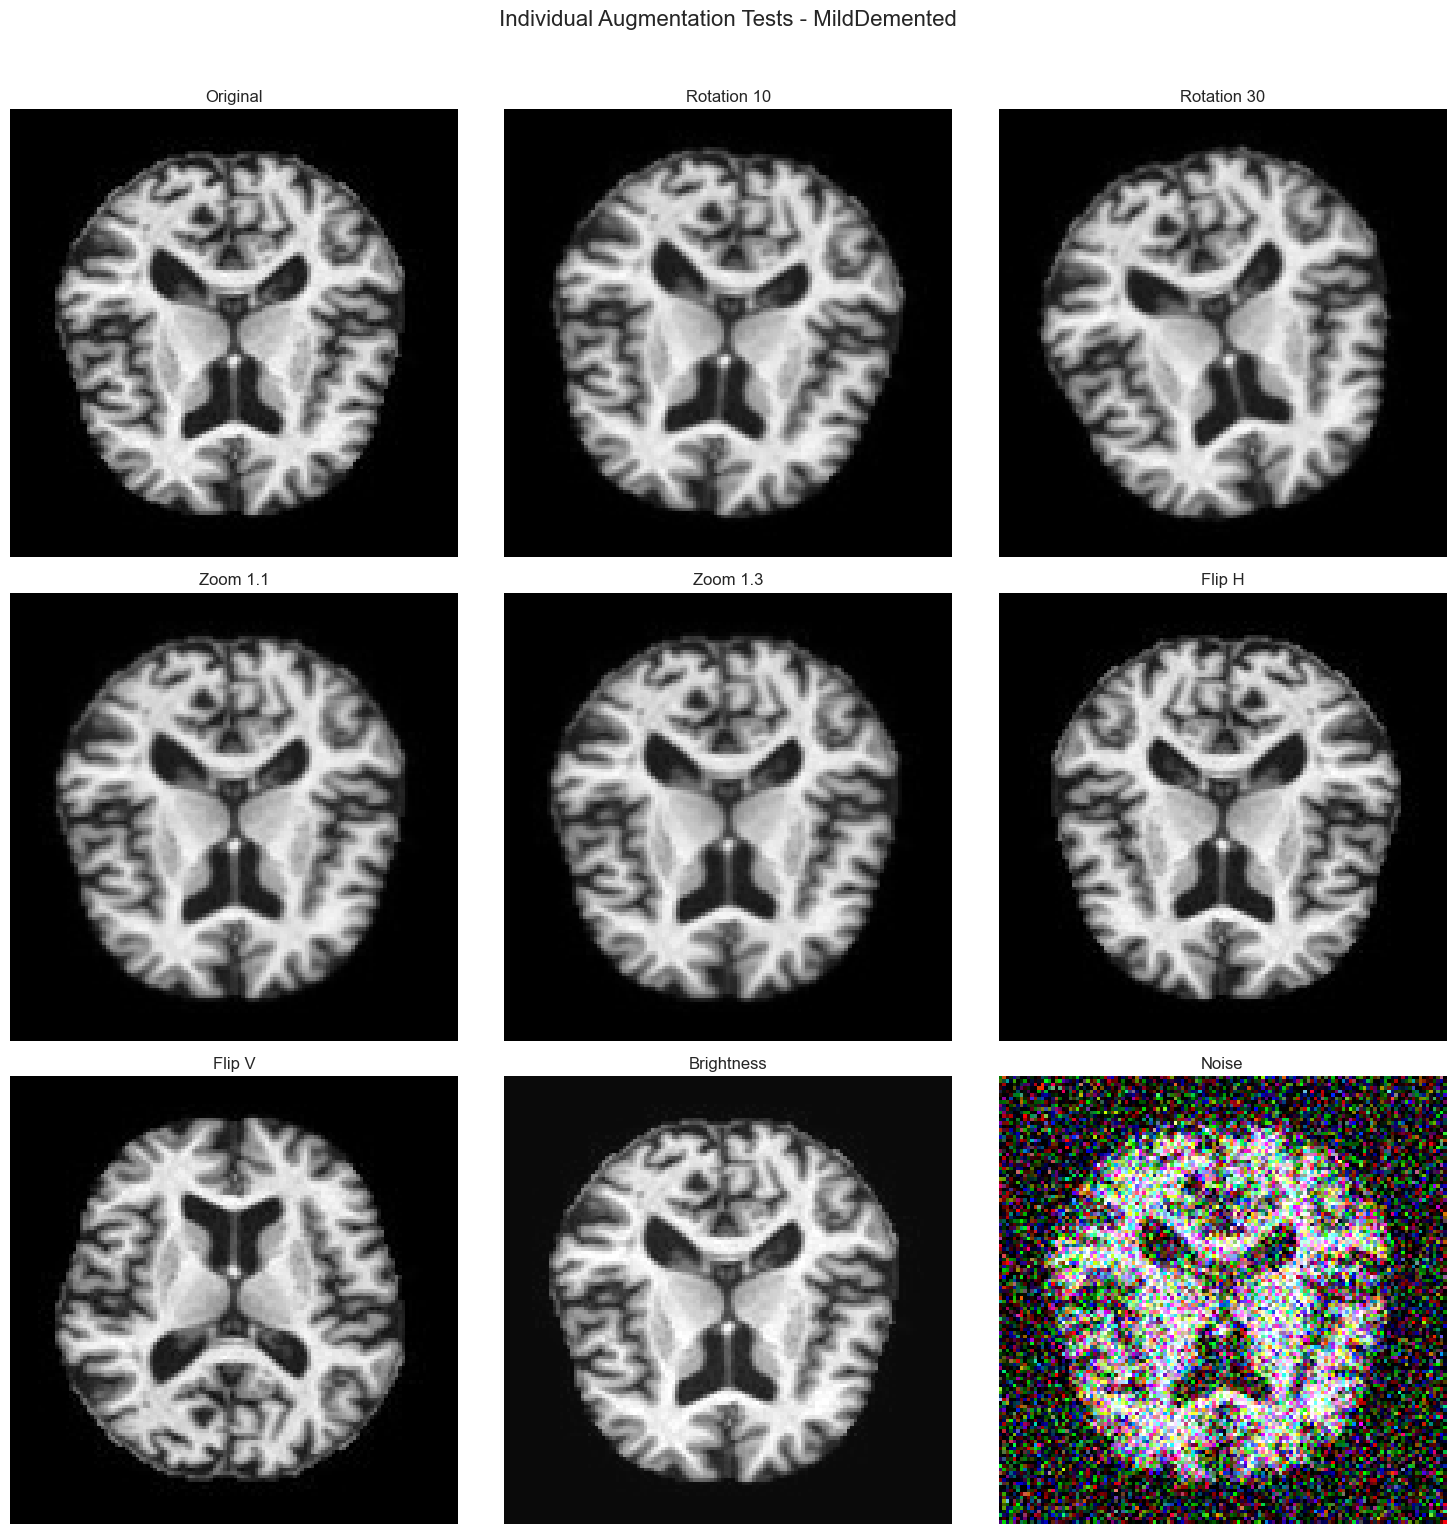

In [9]:
# Individual augmnetation tests 
# Test individual augmentations
test_class = list(sample_images.keys())[0]
test_sample = sample_images[test_class][0]
test_image = test_sample['rgb']

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Original image
axes[0].imshow(test_image)
axes[0].set_title('Original')
axes[0].axis('off')

# Apply each augmentation
for idx, (aug_name, aug) in enumerate(individual_augs.items(), start=1):
    if idx >= 9:
        break
    
    augmented = aug(image=test_image)['image']
    axes[idx].imshow(augmented)
    axes[idx].set_title(aug_name.replace('_', ' ').title())
    axes[idx].axis('off')

plt.suptitle(f'Individual Augmentation Tests - {test_class}', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/individual_augmentations.png', dpi=300, bbox_inches='tight')
plt.show()

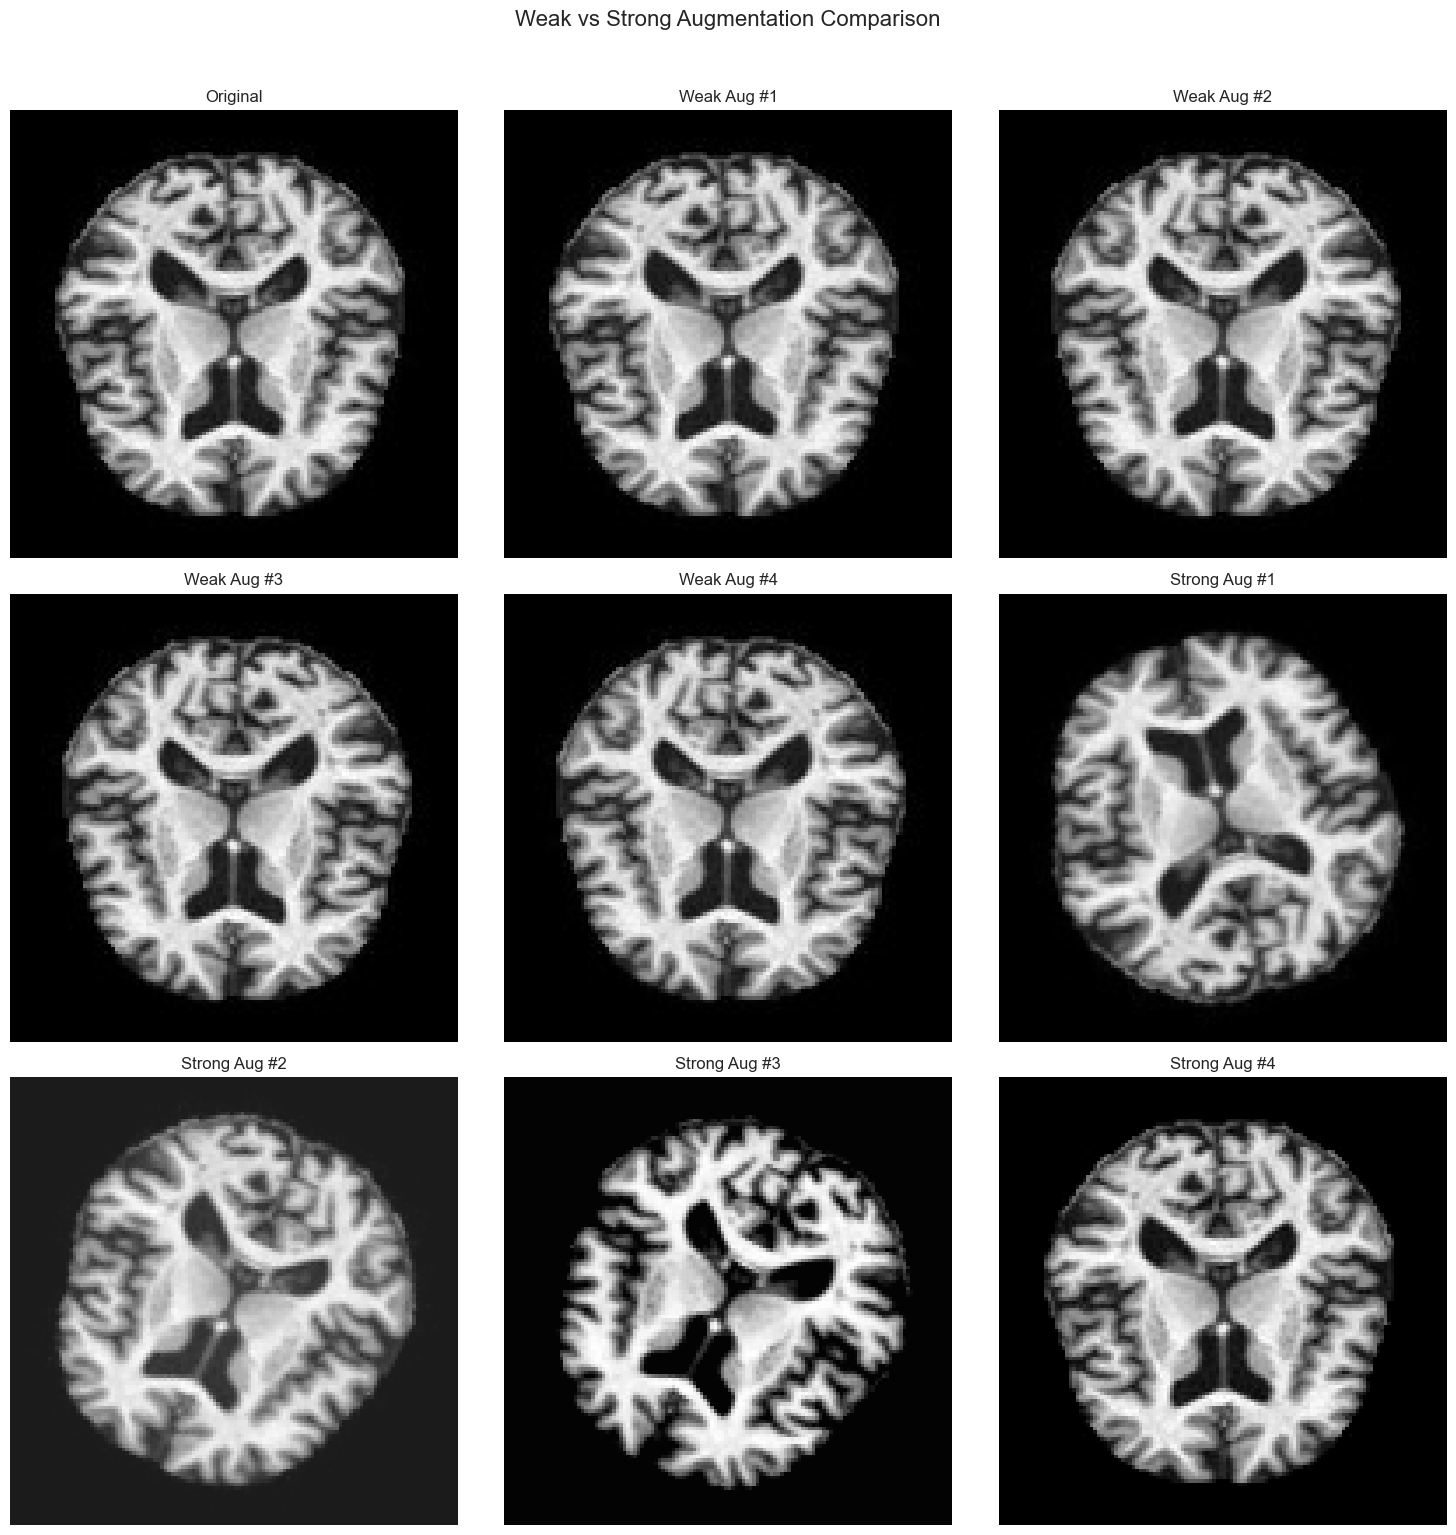

In [10]:
# Weak vs Strong augmentation comparison
# Compare weak vs strong augmentation on multiple samples
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Original
axes[0].imshow(test_image)
axes[0].set_title('Original')
axes[0].axis('off')

# Apply weak augmentation multiple times
for i in range(4):
    augmented = weak_aug(image=test_image)['image']
    axes[i+1].imshow(augmented)
    axes[i+1].set_title(f'Weak Aug #{i+1}')
    axes[i+1].axis('off')

# Apply strong augmentation multiple times
for i in range(4):
    augmented = strong_aug(image=test_image)['image']
    axes[i+5].imshow(augmented)
    axes[i+5].set_title(f'Strong Aug #{i+1}')
    axes[i+5].axis('off')

plt.suptitle('Weak vs Strong Augmentation Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/weak_vs_strong.png', dpi=300, bbox_inches='tight')
plt.show()


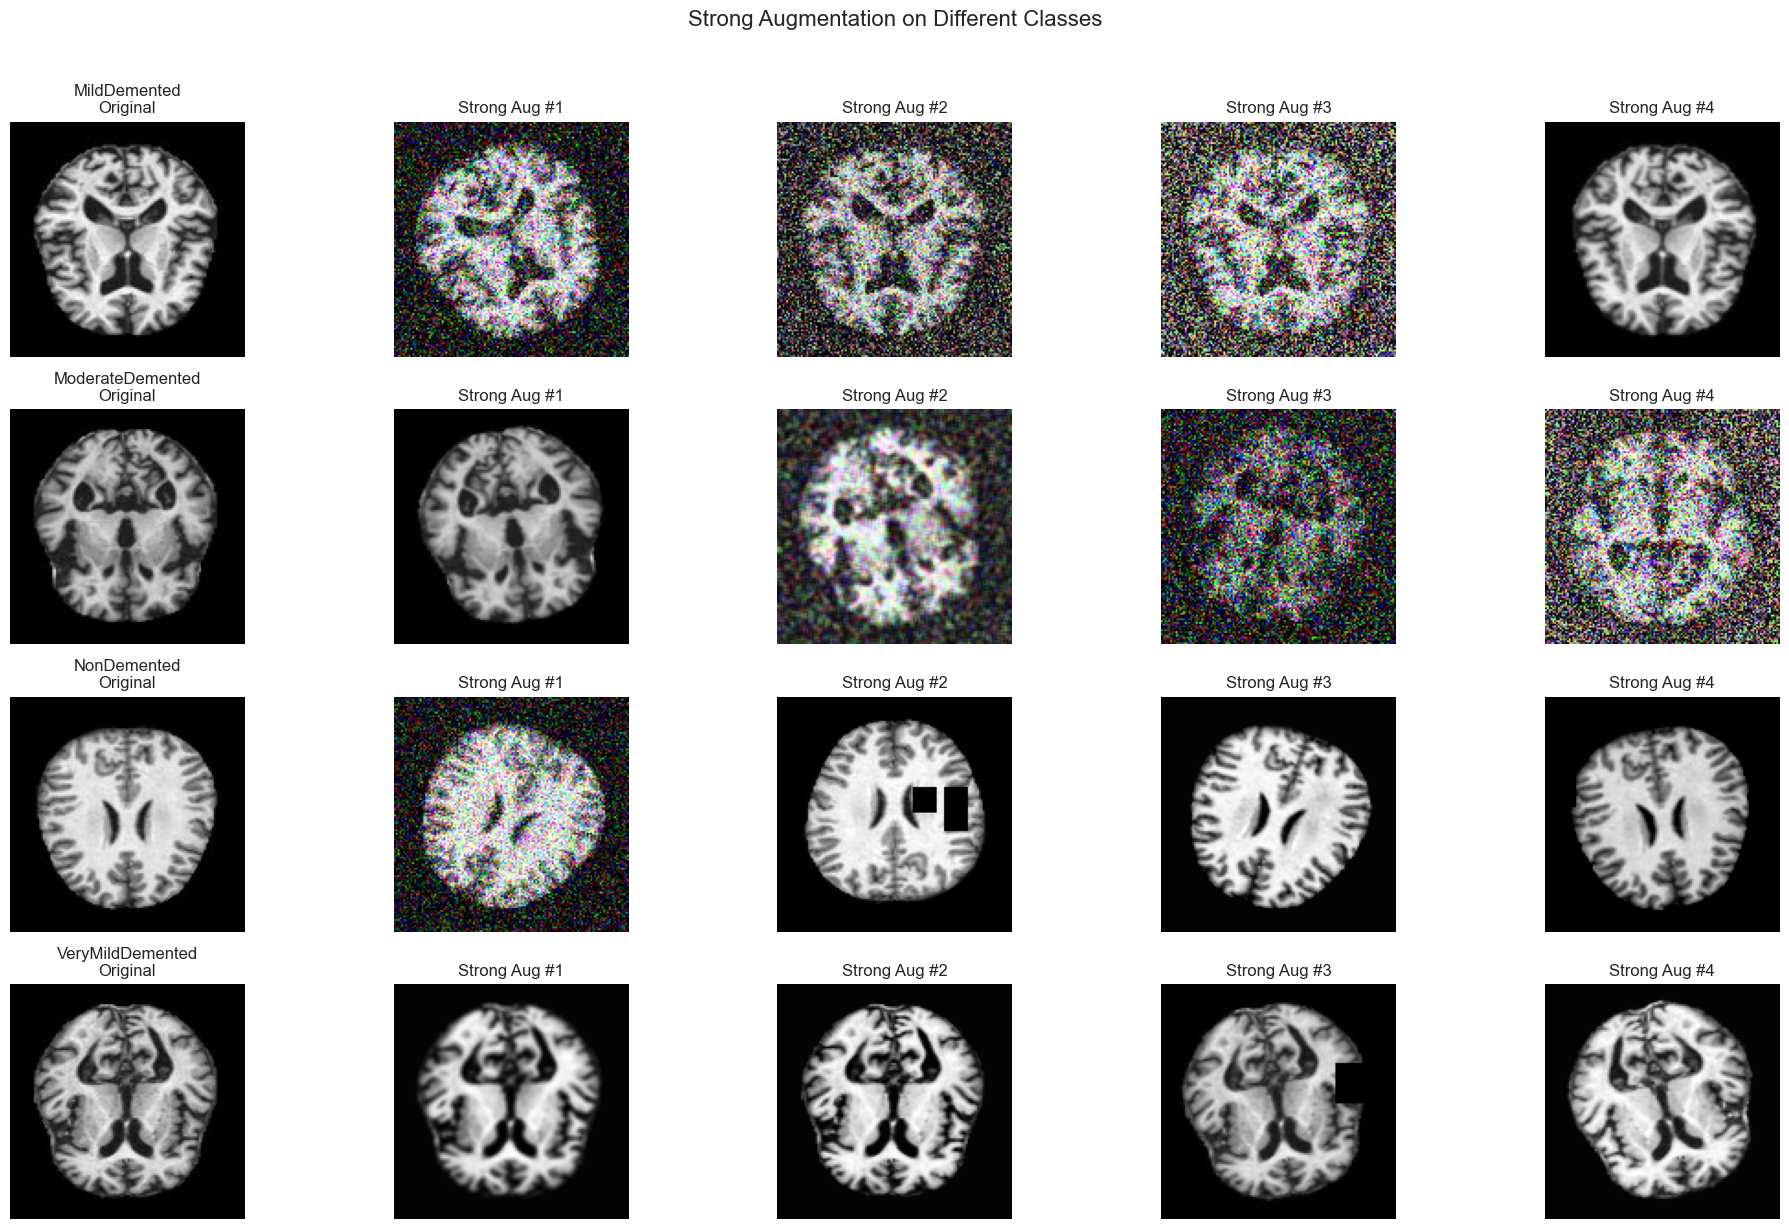

In [11]:
# augentation by class
# Test strong augmentation on samples from each class
fig, axes = plt.subplots(len(sample_images), 5, figsize=(20, len(sample_images)*3))

for row, (class_name, samples) in enumerate(sample_images.items()):
    sample = samples[0]  # First sample from each class
    img = sample['rgb']
    
    # Original
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'{class_name}\nOriginal')
    axes[row, 0].axis('off')
    
    # Apply strong augmentation 4 times
    for col in range(1, 5):
        augmented = strong_aug(image=img)['image']
        axes[row, col].imshow(augmented)
        axes[row, col].set_title(f'Strong Aug #{col}')
        axes[row, col].axis('off')

plt.suptitle('Strong Augmentation on Different Classes', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/augmentation_by_class.png', dpi=300, bbox_inches='tight')
plt.show()


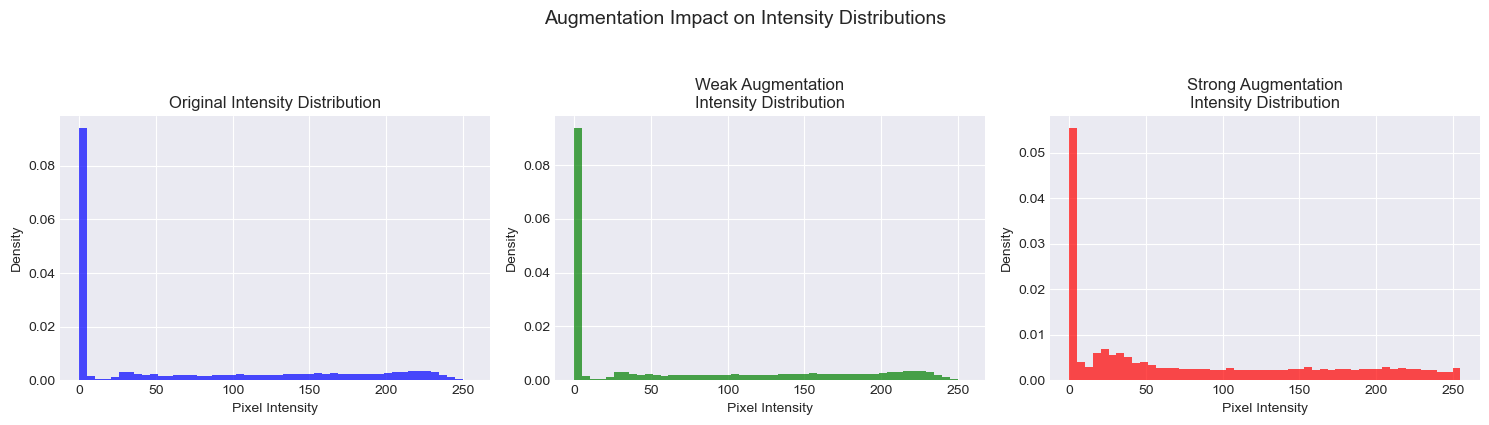

In [12]:
# Augmentation impact on intensity distrubution 
def analyze_augmentation_intensity_impact(image, aug_pipeline, num_samples=100):
    """Analyze how augmentation affects pixel intensity distribution"""
    original_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    original_hist = original_gray.flatten()
    
    augmented_pixels = []
    
    for _ in range(num_samples):
        augmented = aug_pipeline(image=image)['image']
        aug_gray = cv2.cvtColor(augmented, cv2.COLOR_RGB2GRAY)
        augmented_pixels.extend(aug_gray.flatten())
    
    return original_hist, np.array(augmented_pixels)

# Compare intensity distributions
original_hist, weak_aug_pixels = analyze_augmentation_intensity_impact(test_image, weak_aug)
_, strong_aug_pixels = analyze_augmentation_intensity_impact(test_image, strong_aug)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original histogram
axes[0].hist(original_hist, bins=50, alpha=0.7, color='blue', density=True)
axes[0].set_title('Original Intensity Distribution')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Density')

# Weak augmentation histogram
axes[1].hist(weak_aug_pixels, bins=50, alpha=0.7, color='green', density=True)
axes[1].set_title('Weak Augmentation\nIntensity Distribution')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Density')

# Strong augmentation histogram
axes[2].hist(strong_aug_pixels, bins=50, alpha=0.7, color='red', density=True)
axes[2].set_title('Strong Augmentation\nIntensity Distribution')
axes[2].set_xlabel('Pixel Intensity')
axes[2].set_ylabel('Density')

plt.suptitle('Augmentation Impact on Intensity Distributions', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/augmentation_intensity_impact.png', dpi=300, bbox_inches='tight')
plt.show()

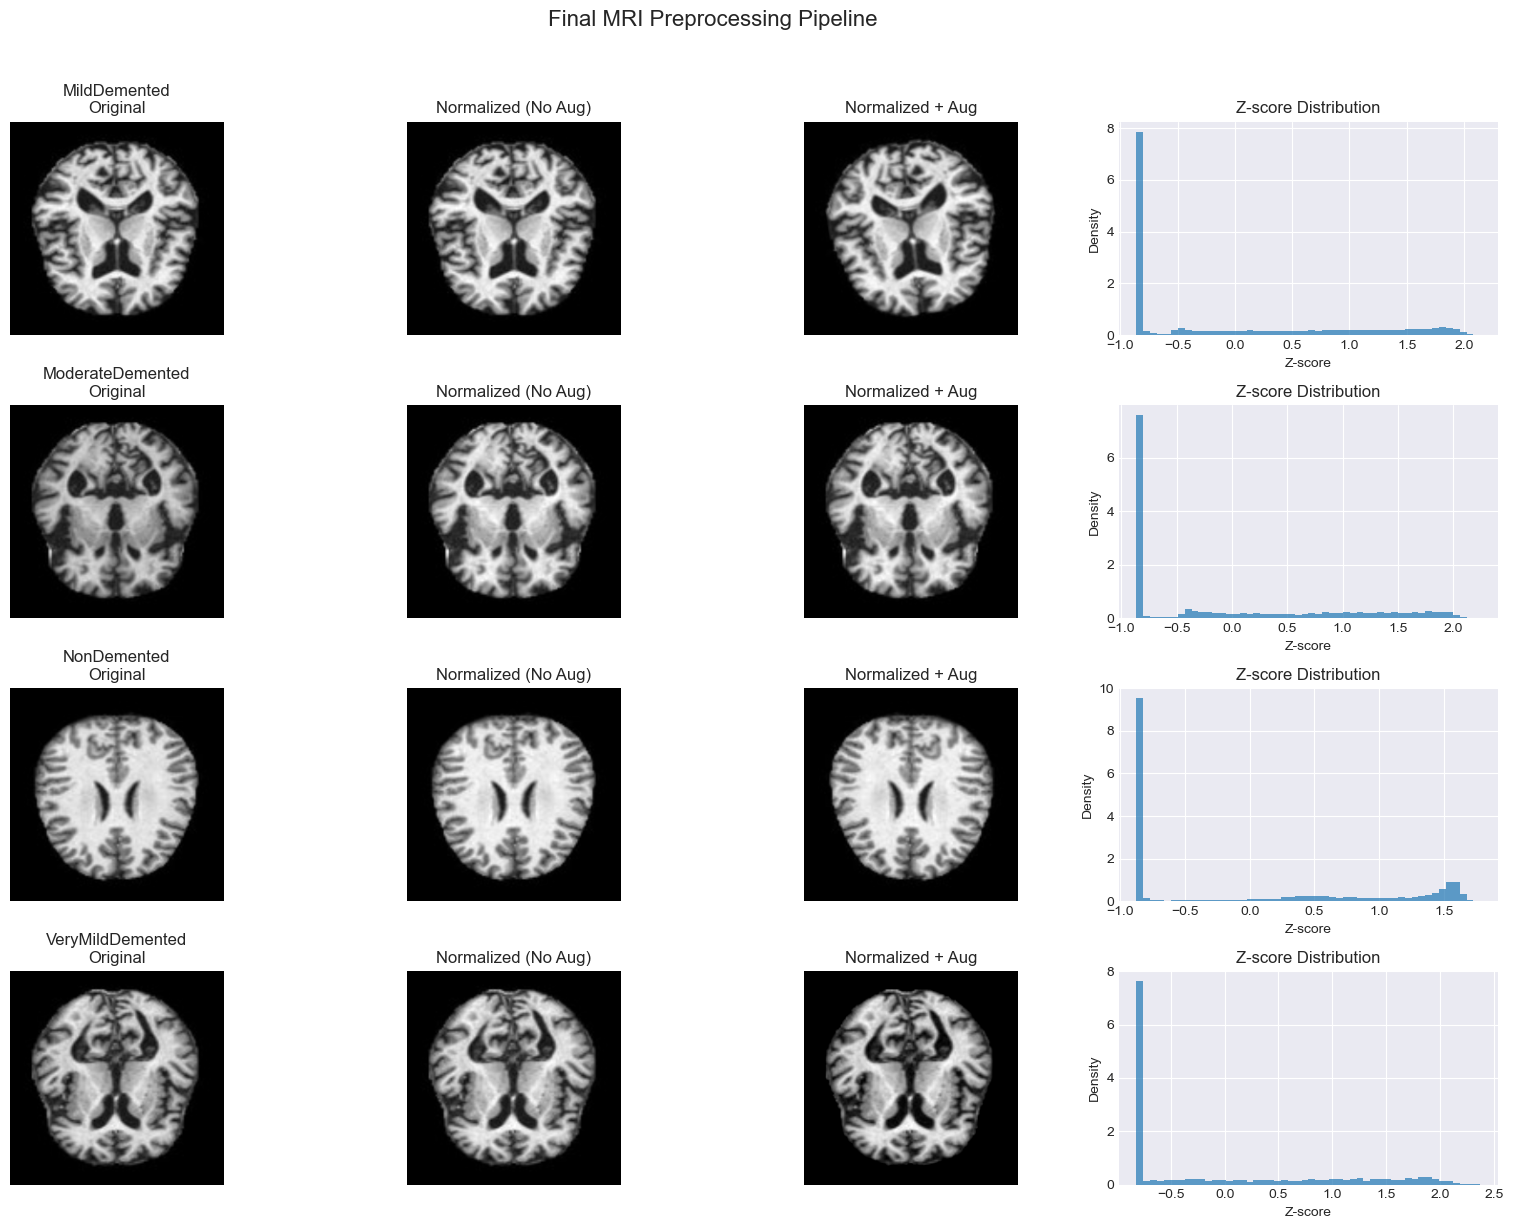

In [13]:
class PreprocessingPipeline:
    """
    Optimized preprocessing pipeline for Alzheimer MRI classification
    - No skull stripping (dataset already preprocessed)
    - Light, controlled augmentation
    - Z-score normalization (grayscale-based)
    """
    
    def __init__(self, img_size=(224, 224), use_augmentation=True):
        self.img_size = img_size
        self.use_augmentation = use_augmentation
        
        # Light medical-safe augmentation
        if use_augmentation:
            self.augmentation = A.Compose([
                A.HorizontalFlip(p=0.5),                  # Brain is symmetric
                A.Rotate(limit=10, p=0.3),                # Small rotation only
                A.RandomBrightnessContrast(
                    brightness_limit=0.1, 
                    contrast_limit=0.1, 
                    p=0.2
                ),
                A.ShiftScaleRotate(
                    shift_limit=0.03,
                    scale_limit=0.05,
                    rotate_limit=0,
                    p=0.2
                ),
            ])
        else:
            self.augmentation = None

    def preprocess(self, image, apply_augmentation=False):
        """Full preprocessing pipeline"""
        
        # Resize
        if image.shape[:2] != self.img_size:
            image = cv2.resize(image, self.img_size)

        # Convert to grayscale (MRI is intensity-based)
        if len(image.shape) == 3:
            image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # Apply augmentation BEFORE normalization
        if apply_augmentation and self.augmentation is not None:
            augmented = self.augmentation(image=image)
            image = augmented['image']

        # Convert to float
        image = image.astype(np.float32)

        # Z-score normalization (per image)
        mean = np.mean(image)
        std = np.std(image)

        if std > 0:
            image = (image - mean) / std
        else:
            image = image - mean

        # Expand to 3 channels if using pretrained CNN (ResNet, etc.)
        image = np.stack([image] * 3, axis=-1)

        return image
    
# Create pipelines
pipeline_no_aug = PreprocessingPipeline(use_augmentation=False)
pipeline_aug = PreprocessingPipeline(use_augmentation=True)

# Visualize results
fig, axes = plt.subplots(len(sample_images), 4, 
                         figsize=(16, len(sample_images)*3))

for row, (class_name, samples) in enumerate(sample_images.items()):
    
    sample = samples[0]
    img = sample['rgb']

    # -----------------------
    # Original (resized)
    # -----------------------
    img_resized = cv2.resize(img, (224, 224))
    axes[row, 0].imshow(img_resized)
    axes[row, 0].set_title(f'{class_name}\nOriginal')
    axes[row, 0].axis('off')

    # -----------------------
    # No Augmentation
    # -----------------------
    no_aug = pipeline_no_aug.preprocess(img, apply_augmentation=False)

    # Convert Z-score back to displayable grayscale
    no_aug_display = no_aug[:,:,0]  # Take one channel
    no_aug_display = (no_aug_display - no_aug_display.min()) / \
                     (no_aug_display.max() - no_aug_display.min() + 1e-8)

    axes[row, 1].imshow(no_aug_display, cmap='gray')
    axes[row, 1].set_title('Normalized (No Aug)')
    axes[row, 1].axis('off')

    # -----------------------
    # With Augmentation
    # -----------------------
    aug = pipeline_aug.preprocess(img, apply_augmentation=True)

    aug_display = aug[:,:,0]
    aug_display = (aug_display - aug_display.min()) / \
                  (aug_display.max() - aug_display.min() + 1e-8)

    axes[row, 2].imshow(aug_display, cmap='gray')
    axes[row, 2].set_title('Normalized + Aug')
    axes[row, 2].axis('off')

    # -----------------------
    # Histogram of Z-score
    # -----------------------
    axes[row, 3].hist(aug[:,:,0].flatten(), 
                      bins=50, alpha=0.7, density=True)
    axes[row, 3].set_title('Z-score Distribution')
    axes[row, 3].set_xlabel('Z-score')
    axes[row, 3].set_ylabel('Density')

plt.suptitle('Final MRI Preprocessing Pipeline', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reports/figures/preprocessing/final_pipeline.png', 
            dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# Generate preprocessing decisions document
from datetime import datetime

decisions = f"""
# Preprocessing Pipeline Decisions
**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 1. Skull Stripping
**Decision:** EXCLUDE
**Rationale:** 
- Skull stripping was tested separately.
- The dataset images are already sufficiently clean.
- Threshold-based stripping did not significantly improve visual quality.
- To avoid removing useful brain tissue, it was excluded from the final pipeline.

## 2. Image Resizing
**Target Size:** (224, 224)
**Rationale:** 
- Standard input size for pretrained CNN architectures (e.g., ResNet, EfficientNet).
- Ensures compatibility with transfer learning.
- Balances spatial detail and computational efficiency.

## 3. Color Space Handling
**Decision:** Convert to Grayscale → Expand to 3 Channels
**Rationale:**
- MRI images are intensity-based, not color-based.
- Converting to grayscale preserves medical relevance.
- Final tensor is stacked into 3 identical channels to remain compatible with pretrained ImageNet models.

## 4. Normalization
**Method:** Z-score normalization (per image)
**Formula:** (x - μ) / σ
**Rationale:**
- Centers each image around zero mean.
- Scales to unit variance.
- Improves optimization stability.
- Standard practice in medical imaging.

## 5. Augmentation Strategy
**Type:** Light / Medical-safe augmentation
**Applied Only During Training**

**Transformations Included:**
- Horizontal Flip (p=0.5)
- Rotation (±10°, p=0.3)
- Random Brightness/Contrast (limit=0.1, p=0.2)
- ShiftScaleRotate:
    - Shift limit = 0.03
    - Scale limit = 0.05
    - No additional rotation
    - p=0.2

**Rationale:**
- Maintains anatomical realism.
- Avoids aggressive distortions.
- Increases dataset variability while preserving diagnostic features.
- Designed specifically for MRI constraints.

## 6. Final Pipeline Summary

```python
class FinalPreprocessingPipeline:
    def preprocess(self, image, apply_augmentation=False):

        # 1. Resize to (224, 224)
        image = cv2.resize(image, (224, 224))

        # 2. Convert to grayscale
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

        # 3. Apply light augmentation (training only)
        if apply_augmentation:
            image = augmentation(image=image)["image"]

        # 4. Convert to float32
        image = image.astype(np.float32)

        # 5. Z-score normalization (per image)
        mean = np.mean(image)
        std = np.std(image)
        image = (image - mean) / std if std > 0 else image - mean

        # 6. Expand to 3 channels for pretrained CNN
        image = np.stack([image] * 3, axis=-1)

        return image
"""


### ✅ What Changed Compared to Your Old Version

- ❌ Skull stripping removed  
- ❌ Strong augmentation removed  
- ❌ RGB normalization removed  
- ✅ Grayscale conversion added  
- ✅ Per-image Z-score (not per-channel)  
- ✅ Light, medically-safe augmentation  
- ✅ Channel stacking for pretrained models  

